In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error

Understanding dataset nature

In [209]:
data = pd.read_csv('AEP_hourly.csv')
data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [210]:
data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [211]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  str    
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.9 MB


Preparing data for time series forecasting

In [212]:
data['Datetime'] = pd.to_datetime(data['Datetime'])

In [213]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[us]
 1   AEP_MW    121273 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.9 MB


In [214]:
data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [215]:
data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [216]:
data.set_index('Datetime', inplace = True)

In [217]:
data.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


EDA

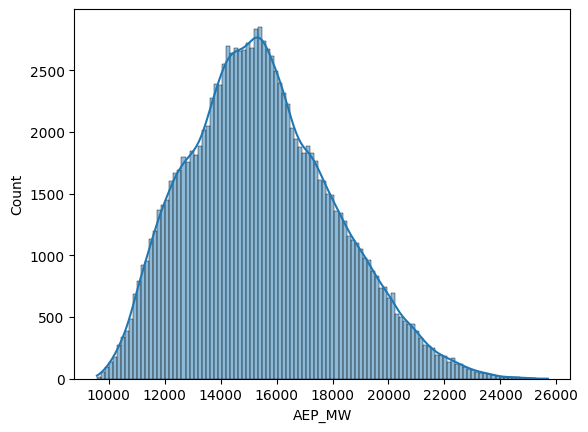

In [218]:
plt.figure()
sns.histplot(data['AEP_MW'], kde = True)
plt.show()

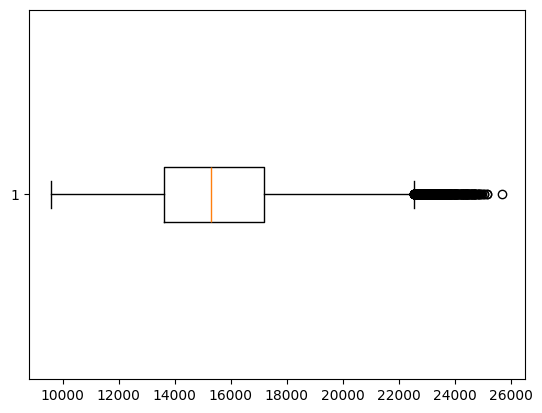

In [219]:
plt.boxplot(data, vert = False)
plt.show()

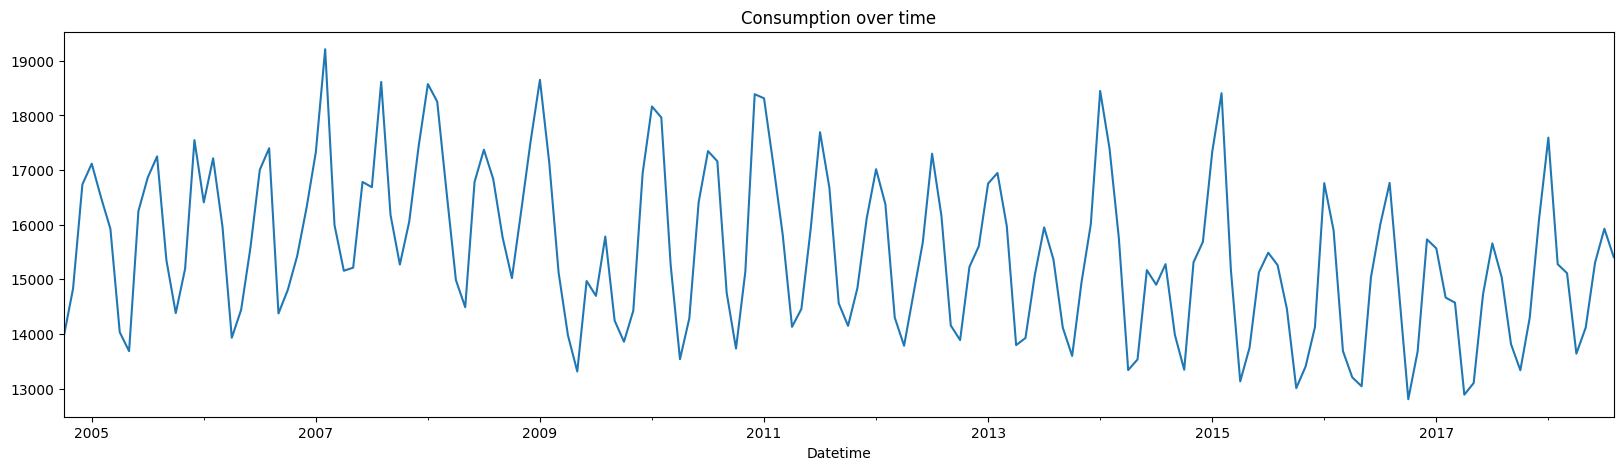

In [220]:
data_2 = data[['AEP_MW']].resample('ME').mean().copy()
data_2['AEP_MW'].plot(title=f"Consumption over time", figsize=(20, 5))
plt.show()

Train test Split

In [221]:
size = int(len(data_2)*0.8)
train_dataset = data_2.iloc[:size].copy()
test_dataset = data_2.iloc[size:].copy()

In [222]:
print(f"p_value: {sts.adfuller(train_dataset['AEP_MW'])[1]}")

p_value: 0.6416605289899769


In [223]:
train_dataset[['AEP_MW']]

,AEP_MW
Datetime,
2004-10-31,13947.537736
2004-11-30,14830.440278
2004-12-31,16737.720430
2005-01-31,17117.088710
2005-02-28,16496.644345
...,...
2015-06-30,15126.598611
2015-07-31,15487.528226
2015-08-31,15260.602151


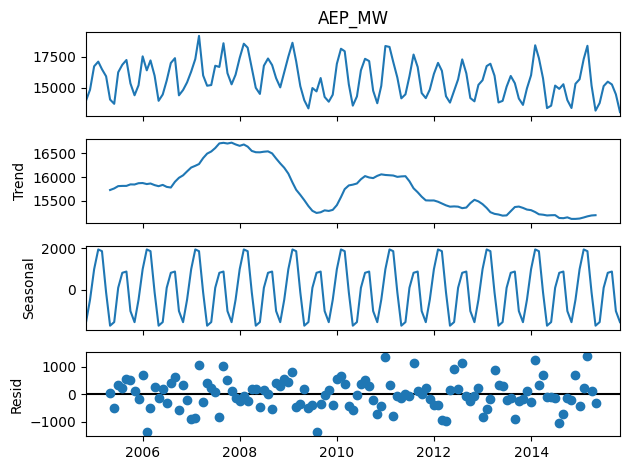

In [224]:
s_dec_additive = seasonal_decompose(train_dataset['AEP_MW'], model='additive')
s_dec_additive.plot()
plt.show()

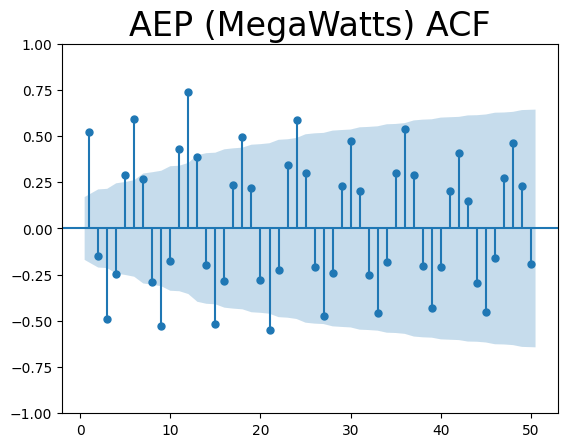

In [225]:
sgt.plot_acf(train_dataset['AEP_MW'], lags=50, zero=False)
plt.title("AEP (MegaWatts) ACF", size=24)    
plt.show()

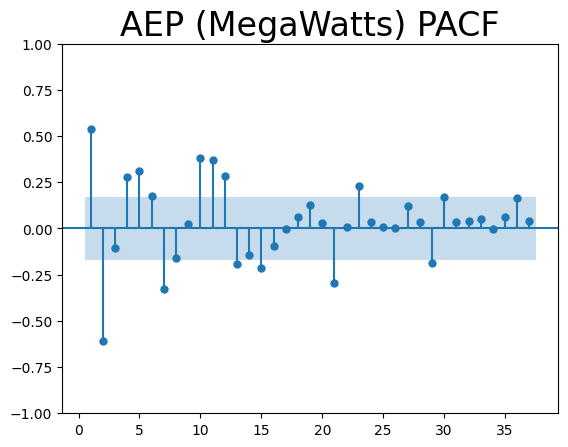

In [226]:
sgt.plot_pacf(train_dataset['AEP_MW'], lags=37, zero=False, method='ols')
plt.title("AEP (MegaWatts) PACF", size=24)
plt.show()

In [227]:
stationary_data = train_dataset[['AEP_MW']].diff(periods = 12).dropna().copy()

In [228]:
stationary_data

,AEP_MW
Datetime,
2005-10-31,433.844498
2005-11-30,364.441667
2005-12-31,810.868280
2006-01-31,-707.252688
2006-02-28,719.383929
...,...
2015-06-30,-41.783333
2015-07-31,585.903226
2015-08-31,-17.698925


In [229]:
print(f"p_value: {sts.adfuller(stationary_data['AEP_MW'])[1]}")

p_value: 0.004762544539967442


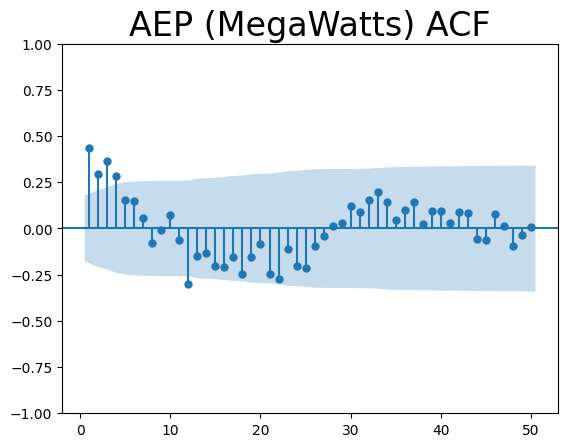

In [230]:
sgt.plot_acf(stationary_data['AEP_MW'], lags=50, zero=False)
plt.title("AEP (MegaWatts) ACF", size=24)    
plt.show()

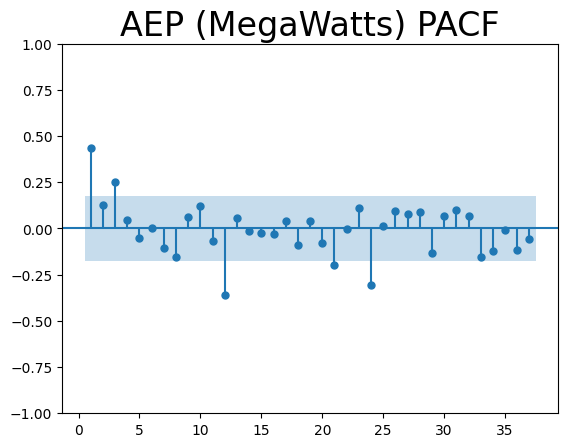

In [231]:
sgt.plot_pacf(stationary_data['AEP_MW'], lags=37, zero=False, method='ols')
plt.title("AEP (MegaWatts) PACF", size=24)
plt.show()

In [232]:
model_sarima = SARIMAX(train_dataset['AEP_MW'],
                       order=(1, 1, 1),           
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit()
print(results_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             AEP_MW   No. Observations:                  133
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -848.039
Date:                            Thu, 04 Jun 2026   AIC                           1706.077
Time:                                    12:47:29   BIC                           1719.395
Sample:                                10-31-2004   HQIC                          1711.475
                                     - 10-31-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2035      0.149      1.363      0.173      -0.089       0.496
ma.L1         -0.7680      0.106   

In [233]:
n_steps = len(test_dataset)
forecast_obj = results_sarima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

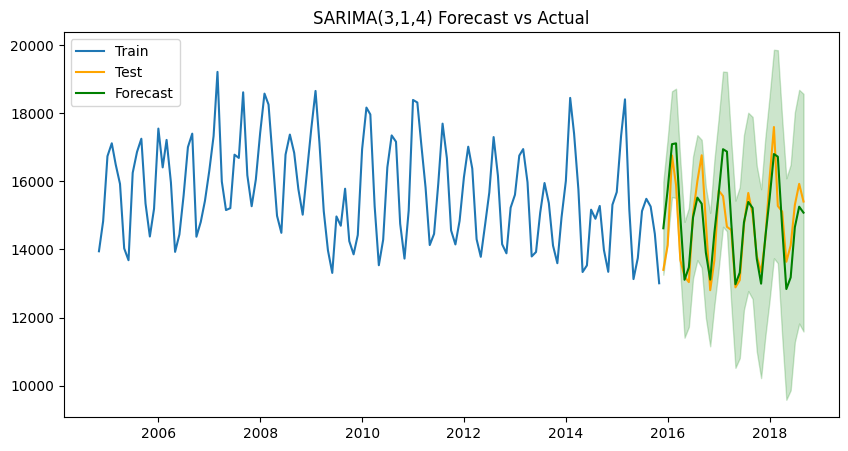

In [234]:
plt.figure(figsize=(10,5))
plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('SARIMA(3,1,4) Forecast vs Actual')
plt.show()

In [235]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 648.80
RMSE: 843.83


In [249]:
model = pm.auto_arima(train_dataset, 
                      start_p=1, start_q=1,
                      max_p=5, max_q=5,
                      m=12,              
                      start_P=0, seasonal=True,
                      d=1, D=1,          
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1944.697, Time=0.45 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1988.983, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1959.970, Time=0.25 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1944.275, Time=0.28 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1967.910, Time=0.04 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1941.499, Time=0.75 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1952.338, Time=0.26 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=1943.497, Time=1.69 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=1943.509, Time=1.58 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1942.141, Time=0.61 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1950.805, Time=0.47 sec
 ARIMA(0,1,1)(2,1,2)[12]             : AIC=1945.451, Time=1.73 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=1963.952, Time=0.18 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=1942.477, Time=0.59 sec
 ARIMA(0,1,2)(1,1,1

In [250]:
model_sarima = SARIMAX(train_dataset['AEP_MW'],
                       order=(0, 1, 1),           
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit()
print(results_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             AEP_MW   No. Observations:                  133
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -848.456
Date:                            Thu, 04 Jun 2026   AIC                           1704.911
Time:                                    12:52:26   BIC                           1715.565
Sample:                                10-31-2004   HQIC                          1709.229
                                     - 10-31-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5930      0.093     -6.390      0.000      -0.775      -0.411
ar.S.L12       0.1444      0.122   

In [251]:
n_steps = len(test_dataset)
forecast_obj = results_sarima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

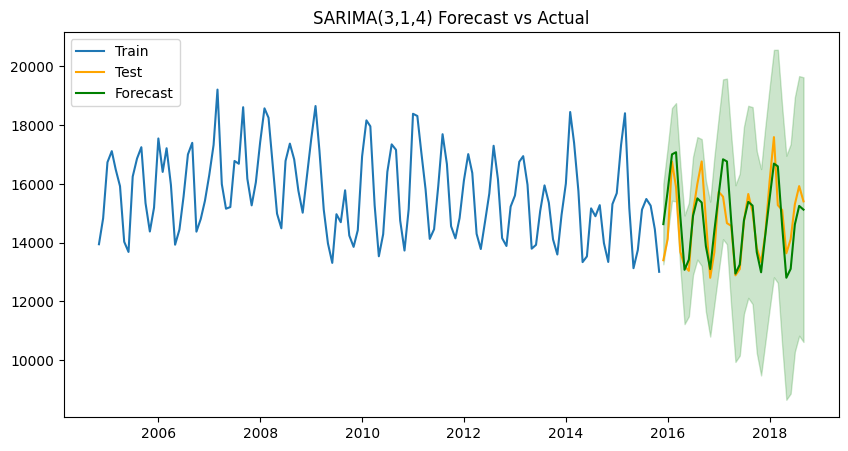

In [252]:
plt.figure(figsize=(10,5))
plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('SARIMA(3,1,4) Forecast vs Actual')
plt.show()

In [253]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 636.41
RMSE: 824.97


In [241]:
model_arima = ARIMA(train_dataset['AEP_MW'], order=(3,1,4))
results_arima = model_arima.fit()
results_arima.summary()

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 AEP_MW   No. Observations:                  133
Model:                 ARIMA(3, 1, 4)   Log Likelihood               -1087.398
Date:                Thu, 04 Jun 2026   AIC                           2190.797
Time:                        12:48:31   BIC                           2213.859
Sample:                    10-31-2004   HQIC                          2200.168
                         - 10-31-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0214      0.029      0.729      0.466      -0.036       0.079
ar.L2         -0.0113      0.029     -0.390      0.697      -0.068       0.045
ar.L3         -0.9832      0.028    -35.301      0.000      -1.038      -0.929
ma.L1         -0.2451      0.105     -2.337      0.019      -0.451      -0.040
ma.L2          0.0358      0.120      0.298      0.766      -0.200       0.272
ma.L3          0.9461      0.138      6.857      0.000       0.676       1.216
ma.L4         -0.1772      0.067     -2.630      0.009      -0.309      -0.045
sigma2      7.528e+05   2.85e-07   2.65e+12      0.000    7.53e+05    7.53e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.89   Jarque-Bera (JB):                 0.56
Prob(Q):                              0.17   Prob(JB):                         0.75
Heteroskedasticity (H):               0.45   Skew:                             0.10
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.15e+28. Standard errors may be unstable.
"""

In [242]:
n_steps = len(test_dataset)
forecast_obj = results_arima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

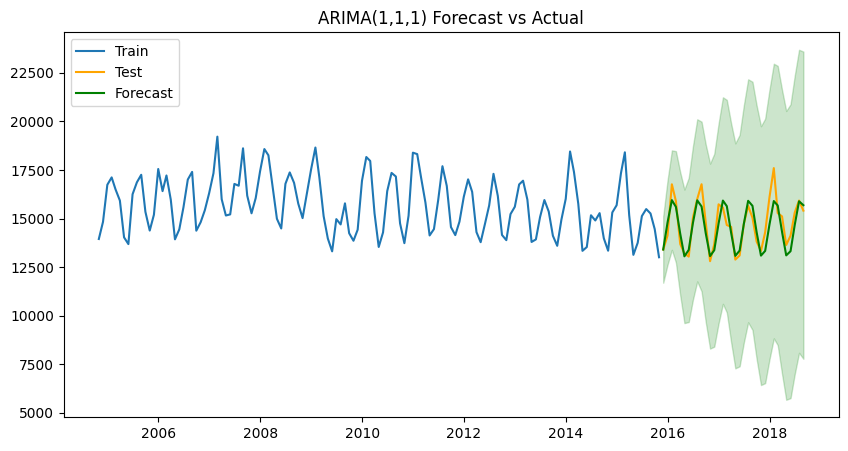

In [243]:
plt.figure(figsize=(10,5))
plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('ARIMA(1,1,1) Forecast vs Actual')
plt.show()

In [244]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 517.45
RMSE: 650.41


In [258]:
train_proph = train_dataset.copy()
train_proph.reset_index(inplace = True)
train_proph.head()

,Datetime,AEP_MW
0,2004-10-31,13947.537736
1,2004-11-30,14830.440278
2,2004-12-31,16737.720430
3,2005-01-31,17117.088710
4,2005-02-28,16496.644345


In [259]:
train_proph = train_proph.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
train_proph.head()

,ds,y
0,2004-10-31,13947.537736
1,2004-11-30,14830.440278
2,2004-12-31,16737.720430
3,2005-01-31,17117.088710
4,2005-02-28,16496.644345


In [263]:
model = Prophet()
model.fit(train_proph)

13:43:05 - cmdstanpy - INFO - Chain [1] start processing
13:43:05 - cmdstanpy - INFO - Chain [1] done processing


In [264]:
test_proph = test_dataset.copy()
test_proph.reset_index(inplace = True)
test_proph.head()

,Datetime,AEP_MW
0,2015-11-30,13403.000000
1,2015-12-31,14123.189516
2,2016-01-31,16760.747312
3,2016-02-29,15895.386494
4,2016-03-31,13687.551817


In [265]:
test_proph = test_proph.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
test_proph.head()

,ds,y
0,2015-11-30,13403.000000
1,2015-12-31,14123.189516
2,2016-01-31,16760.747312
3,2016-02-29,15895.386494
4,2016-03-31,13687.551817


In [266]:
forecast = model.predict(test_proph)

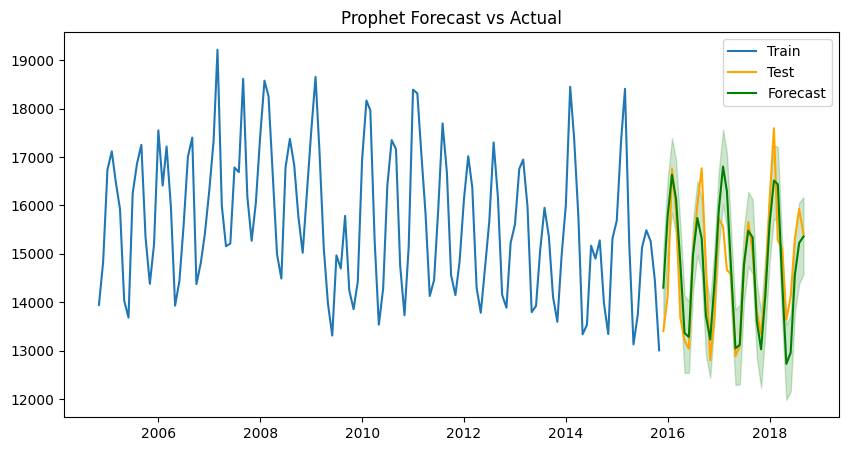

In [267]:
plt.figure(figsize=(10,5))
plt.plot(train_proph['ds'], train_proph['y'], label='Train')
plt.plot(test_proph['ds'], test_proph['y'], label='Test', color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='green')
plt.fill_between(forecast['ds'],
                 forecast['yhat_upper'],
                 forecast['yhat_lower'],
                 color='green', alpha=0.2)
plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.show()

In [269]:
mae = mean_absolute_error(test_proph['y'], forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test_proph['y'], forecast['yhat']))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 581.13
RMSE: 762.77
